## Laplacian Eigenvalue Problem on a Unit Disk

$$
\nabla^2 \, u(r,\theta) = -\lambda \, u(r,\theta)
$$

We solve the Laplacian eigenvalue problem on a disk of radius 1, with vanishing boundary conditions:


$$
u(1,\theta) = 0
$$

$$
\nabla^2 = \frac{1}{r}\frac{\partial}{\partial r} \left( r\frac{\partial}{\partial r} \right)
+
\frac{1}{r^2}\frac{\partial^2}{\partial \theta^2}
$$

For vanishing boundary conditions, the eigenvalues of the Laplacian are negative, so we take $\lambda > 0$

$$
u(r,\theta) = f(r) \, g(\theta) \quad \Rightarrow \quad \frac{1}{r}\frac{\partial}{\partial r} \left( r\frac{\partial f}{\partial r} \right) - \frac{1}{r^2} \frac{g''(\theta)}{g(\theta)} f(r) = -\lambda f(r)
$$

Due to periodic boundary conditions:

$$
g''(\theta) = -n^2 g(\theta) \quad g_n(\theta) = e^{in\theta} \quad n \in \mathbb{Z}
$$

And so

$$
\frac{1}{r}\frac{\partial}{\partial r} \left( r\frac{\partial f}{\partial r} \right) - \frac{n^2}{r^2}f(r) = -\lambda f(r)
$$

Let $ \lambda = k^2 $

Unlike the angular equation, the radial equation does not reduce to simple sinusoidal solutions.
This equation can be transformed into the standard Bessel equation by introducing

$$
z = kr \quad f(r) = Z(z)
$$

$$
\Rightarrow \frac{\partial f}{\partial r} = k \frac{\partial Z}{\partial z}, \quad
\frac{\partial^2 f}{\partial r^2} = k^2 \frac{\partial^2 Z}{\partial z^2}
$$

Substituting into the radial equation gives

$$
k^2 Z''(z) + \frac{k}{r} Z'(z) + \left( k^2 - \frac{n^2}{r^2} \right)Z(z) = 0
$$

$$
k^2 Z''(z) + \frac{k^2}{z} Z'(z) + \left( k^2 - \frac{n^2k^2}{z^2} \right)Z(z) = 0
$$

$$
Z''(z) + \frac{1}{z} Z'(z) + \left( 1 - \frac{n^2}{z^2} \right)Z(z) = 0
$$

This is the <strong>Bessel equation</strong> in its standard form. Bessel functions that do not blow up at $ z = 0 $ are called Bessel functions of the first kind and are denoted with $ J_n $. Bessel functions therefore play the same role in radial geometries that sine and cosine functions play in Cartesian geometries.

$$
\therefore f(r) = J_n(k \, r)
$$

The boundary condition becomes

$$
f(1) = Z(k) = 0
$$

Therefore, $ k $ must be a solution to the equation

$$
J_n(k) = 0
$$

For each $ n $, we obtain a discrete set of values for $ k $ by solving $ J_n(k) = 0 $. 
This equation cannot be solved in closed form. We denote the solutions by $ k_{n,m} $, where $ m $ indexes 
the radial nodes between $ r = 0 $ and $ r = 1 $ $\left( \text{the zeros of }J_n(k) \right)$. The boundary condition 
therefore quantizes the allowed radial modes.

The corresponding eigenfunctions of $ \nabla^2 $ are

$$
u_{n,m}(r,\theta) = J_n (k_{n,m} \, r) \, e^{in\theta} \quad \lambda_{n,m} = k_{n,m}^2
$$
      
with radial part

$$
f_{n,m}(r) = J_n (k_{n,m} \, r)
$$

where $k_{n,m}$ is determined by

$$
J_n(k_{n,m}) = 0
$$

Since the Laplacian is Hermitian under the following inner product, these eigenfunctions are orthogonal

$$
\langle u_{n,m}, u_{\tilde{n},\tilde{m}} \rangle = \int_{0}^{2\pi}\!\!\int_{0}^{1} u_{n,m}^* \, 
u_{\tilde{n},\tilde{m}} \, r\,dr\,d\theta = \delta_{n\tilde{n}}\,\delta_{m\tilde{m}} \, \|u_{n,m}\|^2
$$

Bessel functions are orthogonal when they have the same $ n $ but different $ m $.

## Finding the Eigenvalues

For each angular order $n$, the allowed wavenumbers $k_{n,m}$ are the zeros of $J_n(k)$. We can compute these roots numerically and then sort the resulting modes by increasing wavenumber.

Sorting the modes is useful because lower values of $k_{n,m}$ correspond to lower-frequency modes.

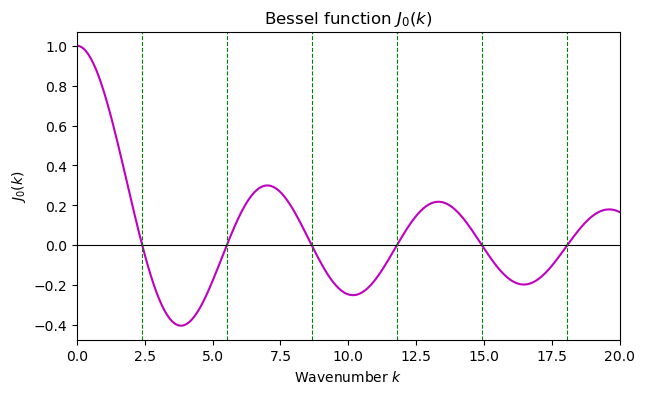

The zeros of J_0(k) are:
k_0,1 = 2.404826
k_0,2 = 5.520078
k_0,3 = 8.653728
k_0,4 = 11.791534
k_0,5 = 14.930918
k_0,6 = 18.071064
k_0,7 = 21.211637
k_0,8 = 24.352472
k_0,9 = 27.493479
k_0,10 = 30.634606


In [1]:
import numpy as np
import scipy
import scipy.special as ss
from mpmath import besseljzero
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Demonstration: Bessel function J_0(k)
# This block is just to visualize J_0 and understand its zeros
# ------------------------------------------------------------

N = 200              # number of points used for plotting
n = 0                # order of the Bessel function (J_0)
k_max = 20           # maximum wavenumber shown on the plot

# Generate wavenumber values
k = np.linspace(0, k_max, N)

# Evaluate the Bessel function J_0(k)
J0 = ss.jv(n, k)


# Compute the first 10 zeros of J_0(k)

# setting the third parameter of besseljzero to 0 gives zeros of the function J_n(k)
# setting it to 1 would give zeros of the derivative J_n'(k)

num_zeros = 10

zeros = [
    float(besseljzero(n, m, 0))   # the m-th zero of J_0(k)
    for m in range(1, num_zeros + 1)
]


# Plot J_0(k)
plt.figure(figsize = (7, 4))
plt.plot(k, J0, 'm-')

# Add horizontal axis (y = 0)
plt.axhline(0, color = "black", linewidth = 0.8)

# Mark the zeros of J_0(k) with vertical dashed lines
for root in zeros:
    plt.axvline(root, linestyle = "--", color = 'g', linewidth = 0.8)

# Fix axis limits so plot does not extend beyond data range
plt.xlim(0, k_max)

plt.xlabel("Wavenumber $k$")
plt.ylabel(rf"$J_{n}(k)$")
plt.title(rf"Bessel function $J_{n}(k)$")

plt.show()

# Display the first 10 zeros
print(f"The zeros of J_{n}(k) are:")
for m, root in enumerate(zeros, start = 1):
    print(f"k_{n},{m} = {root:.6f}")

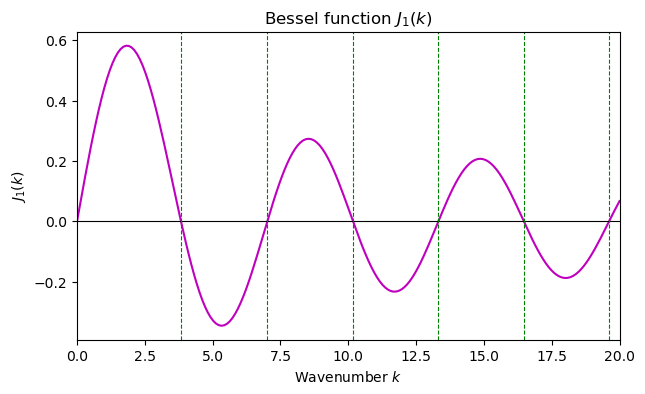

The zeros of J_1(k) are:
k_1,1 = 3.831706
k_1,2 = 7.015587
k_1,3 = 10.173468
k_1,4 = 13.323692
k_1,5 = 16.470630
k_1,6 = 19.615859
k_1,7 = 22.760084
k_1,8 = 25.903672
k_1,9 = 29.046829
k_1,10 = 32.189680


In [2]:
# Plot J_1(k)

n = 1

J1 = ss.jv(n, k)

zeros = [
    float(besseljzero(n, m, 0))   # the m-th zero of J_1(k)
    for m in range(1, num_zeros + 1)
]

plt.figure(figsize = (7, 4))
plt.plot(k, J1, 'm-')

# Add horizontal axis (y = 0)
plt.axhline(0, color = "black", linewidth = 0.8)

# Mark the zeros of J_1(k) with vertical dashed lines
for root in zeros:
    plt.axvline(root, linestyle = "--", color = 'g', linewidth = 0.8)

# Fix axis limits so plot does not extend beyond data range
plt.xlim(0, k_max)

plt.xlabel("Wavenumber $k$")
plt.ylabel(rf"$J_{n}(k)$")
plt.title(rf"Bessel function $J_{n}(k)$")

plt.show()

# Display the first 10 zeros
print(f"The zeros of J_{n}(k) are:")
for m, root in enumerate(zeros, start = 1):
    print(f"k_{n},{m} = {root:.6f}")

In [3]:
# ------------------------------------------
# Compute and sort eigenmodes by wavenumber
# ------------------------------------------

modes = []   # list of (k, n, m) values

# Loop over angular index n and radial index m
for n in range(0, 11):
    for m in range(1, 11):
        k = float(besseljzero(n, m, 0)) # 0 means zeros of J_n(k)
        modes.append((k, n, m))  # Store mode


# Sort modes by increasing wavenumber (frequency)
modes.sort(key = lambda mode: mode[0])


# Display the first 10 modes
print("First 10 modes (sorted by k):")

for k, n, m in modes[:10]:
    print(f"k_{n},{m} = {k:.6f}")

First 10 modes (sorted by k):
k_0,1 = 2.404826
k_1,1 = 3.831706
k_2,1 = 5.135622
k_0,2 = 5.520078
k_3,1 = 6.380162
k_1,2 = 7.015587
k_4,1 = 7.588342
k_2,2 = 8.417244
k_0,3 = 8.653728
k_5,1 = 8.771484


## Visualizing a Single Mode

Each eigenfunction has a radial part, determined by a Bessel function, and an angular part. To visualize a real-valued mode, we use

$$
u_{n,m}(r,\theta)=J_n(k_{n,m}r)\cos(n\theta)
$$

The following plots show one mode both as a polar contour plot and as a 3D surface.

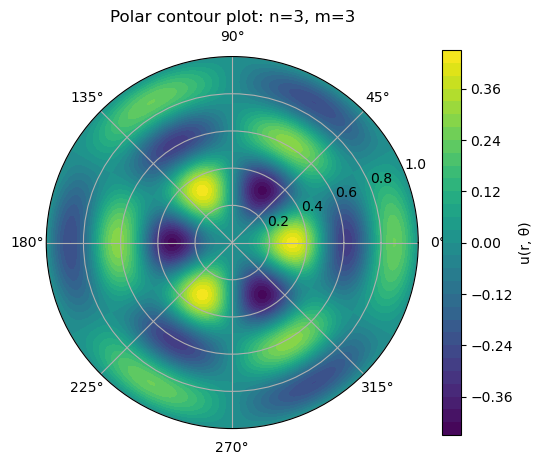

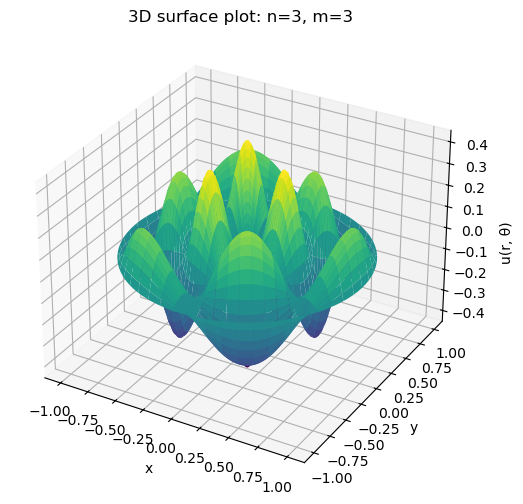

In [4]:
# Set up a grid in r-theta coordinates
radial_points = np.linspace(0, 1, N)
angular_points = np.linspace(0, 2*np.pi, 6*N)  # use ~6x more theta points since 2π ≈ 6

r, theta = np.meshgrid(radial_points, angular_points)

# Choose the mode
n = 3
m = 3

# Zeros of J_n(k)
k = float(besseljzero(n, m, 0))

# Compute the real-valued mode shape
u = ss.jv(n, k*r) * np.cos(n*theta)


# ------------------
# Polar contour plot
# ------------------

fig, ax = plt.subplots(figsize = (6, 5), subplot_kw = {"projection": "polar"})

contour = ax.contourf(theta, r, u, levels = 30, cmap = "viridis")
fig.colorbar(contour, ax = ax, label = "u(r, θ)")

ax.set_title(f"Polar contour plot: n={n}, m={m}")

plt.show()


# ----------------
# 3D surface plot
# ----------------

# Convert polar grid to Cartesian coordinates for 3D plotting
X = r * np.cos(theta)
Y = r * np.sin(theta)

fig, ax = plt.subplots(figsize = (7, 6), subplot_kw = {"projection": "3d"})

surface = ax.plot_surface(X, Y, u, cmap = "viridis")

ax.set_title(f"3D surface plot: n={n}, m={m}")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Manual z-label, more reliable than ax.set_zlabel for 3D plots
ax.text2D(1.06, 0.5, "u(r, θ)", transform = ax.transAxes, rotation = 90)

plt.show()

## Comparing Several Modes

We can now compare several low-order modes. Increasing $n$ changes the angular structure, while increasing $m$ adds more radial oscillations.

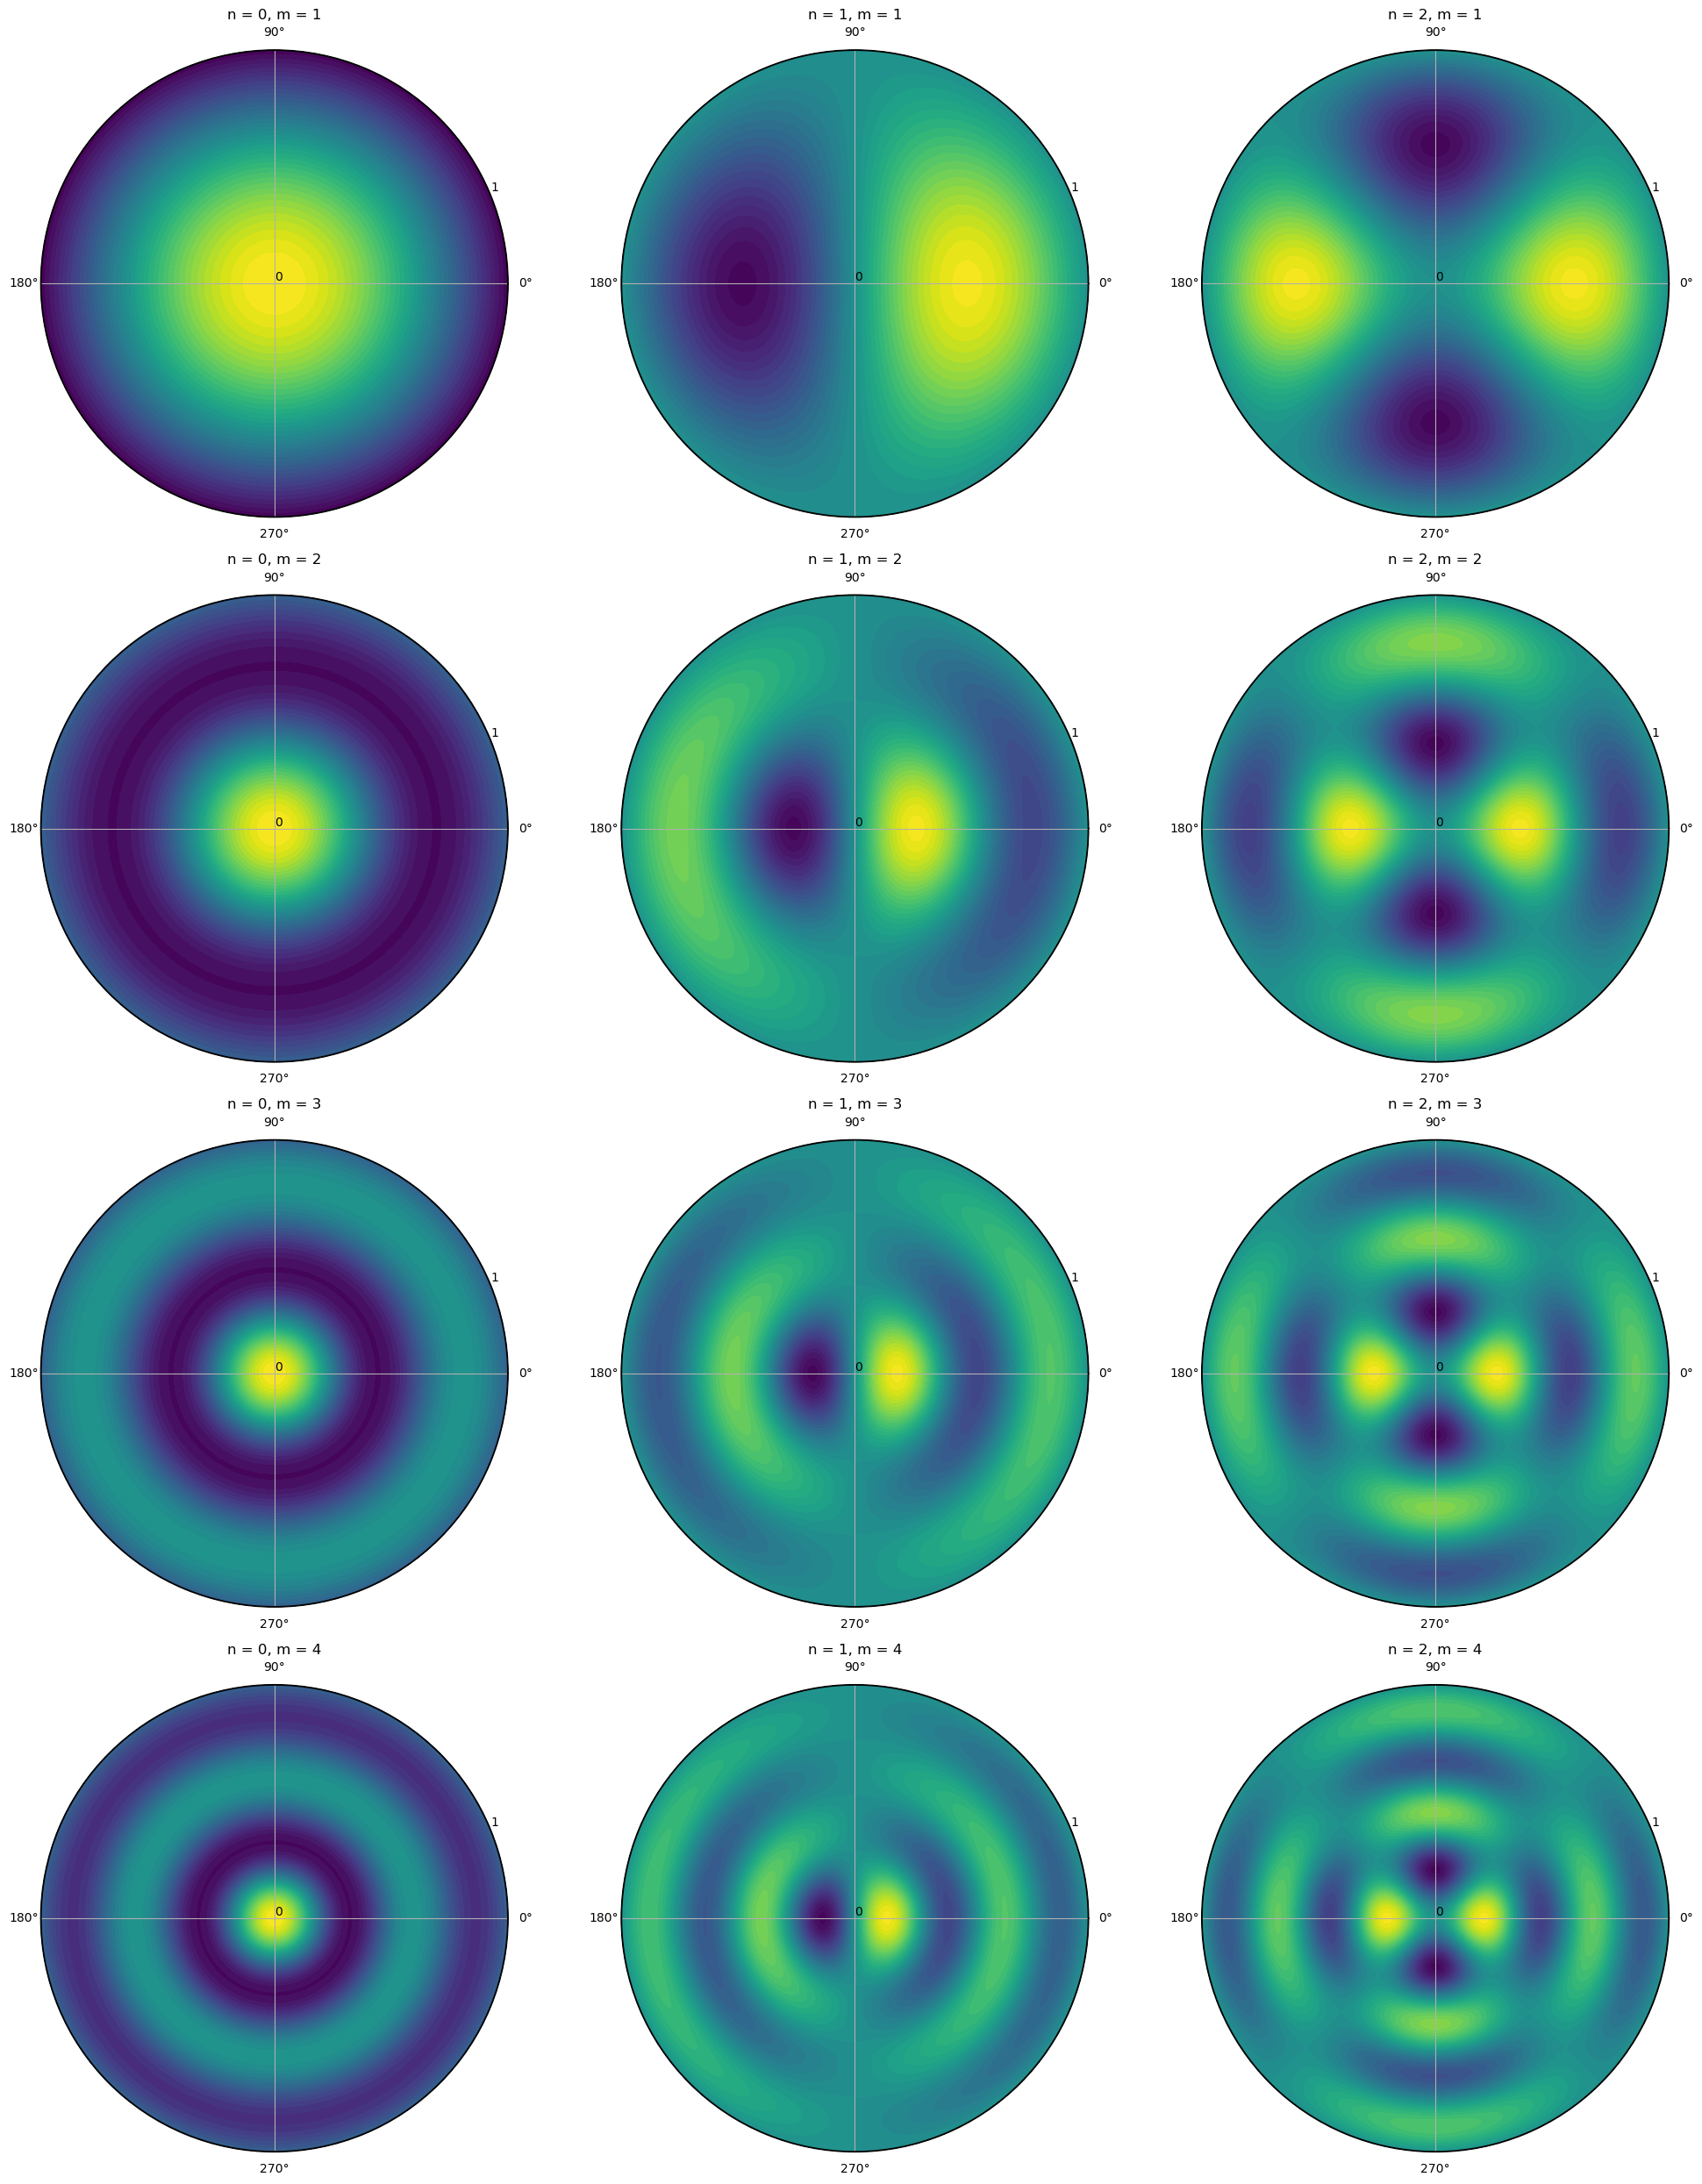

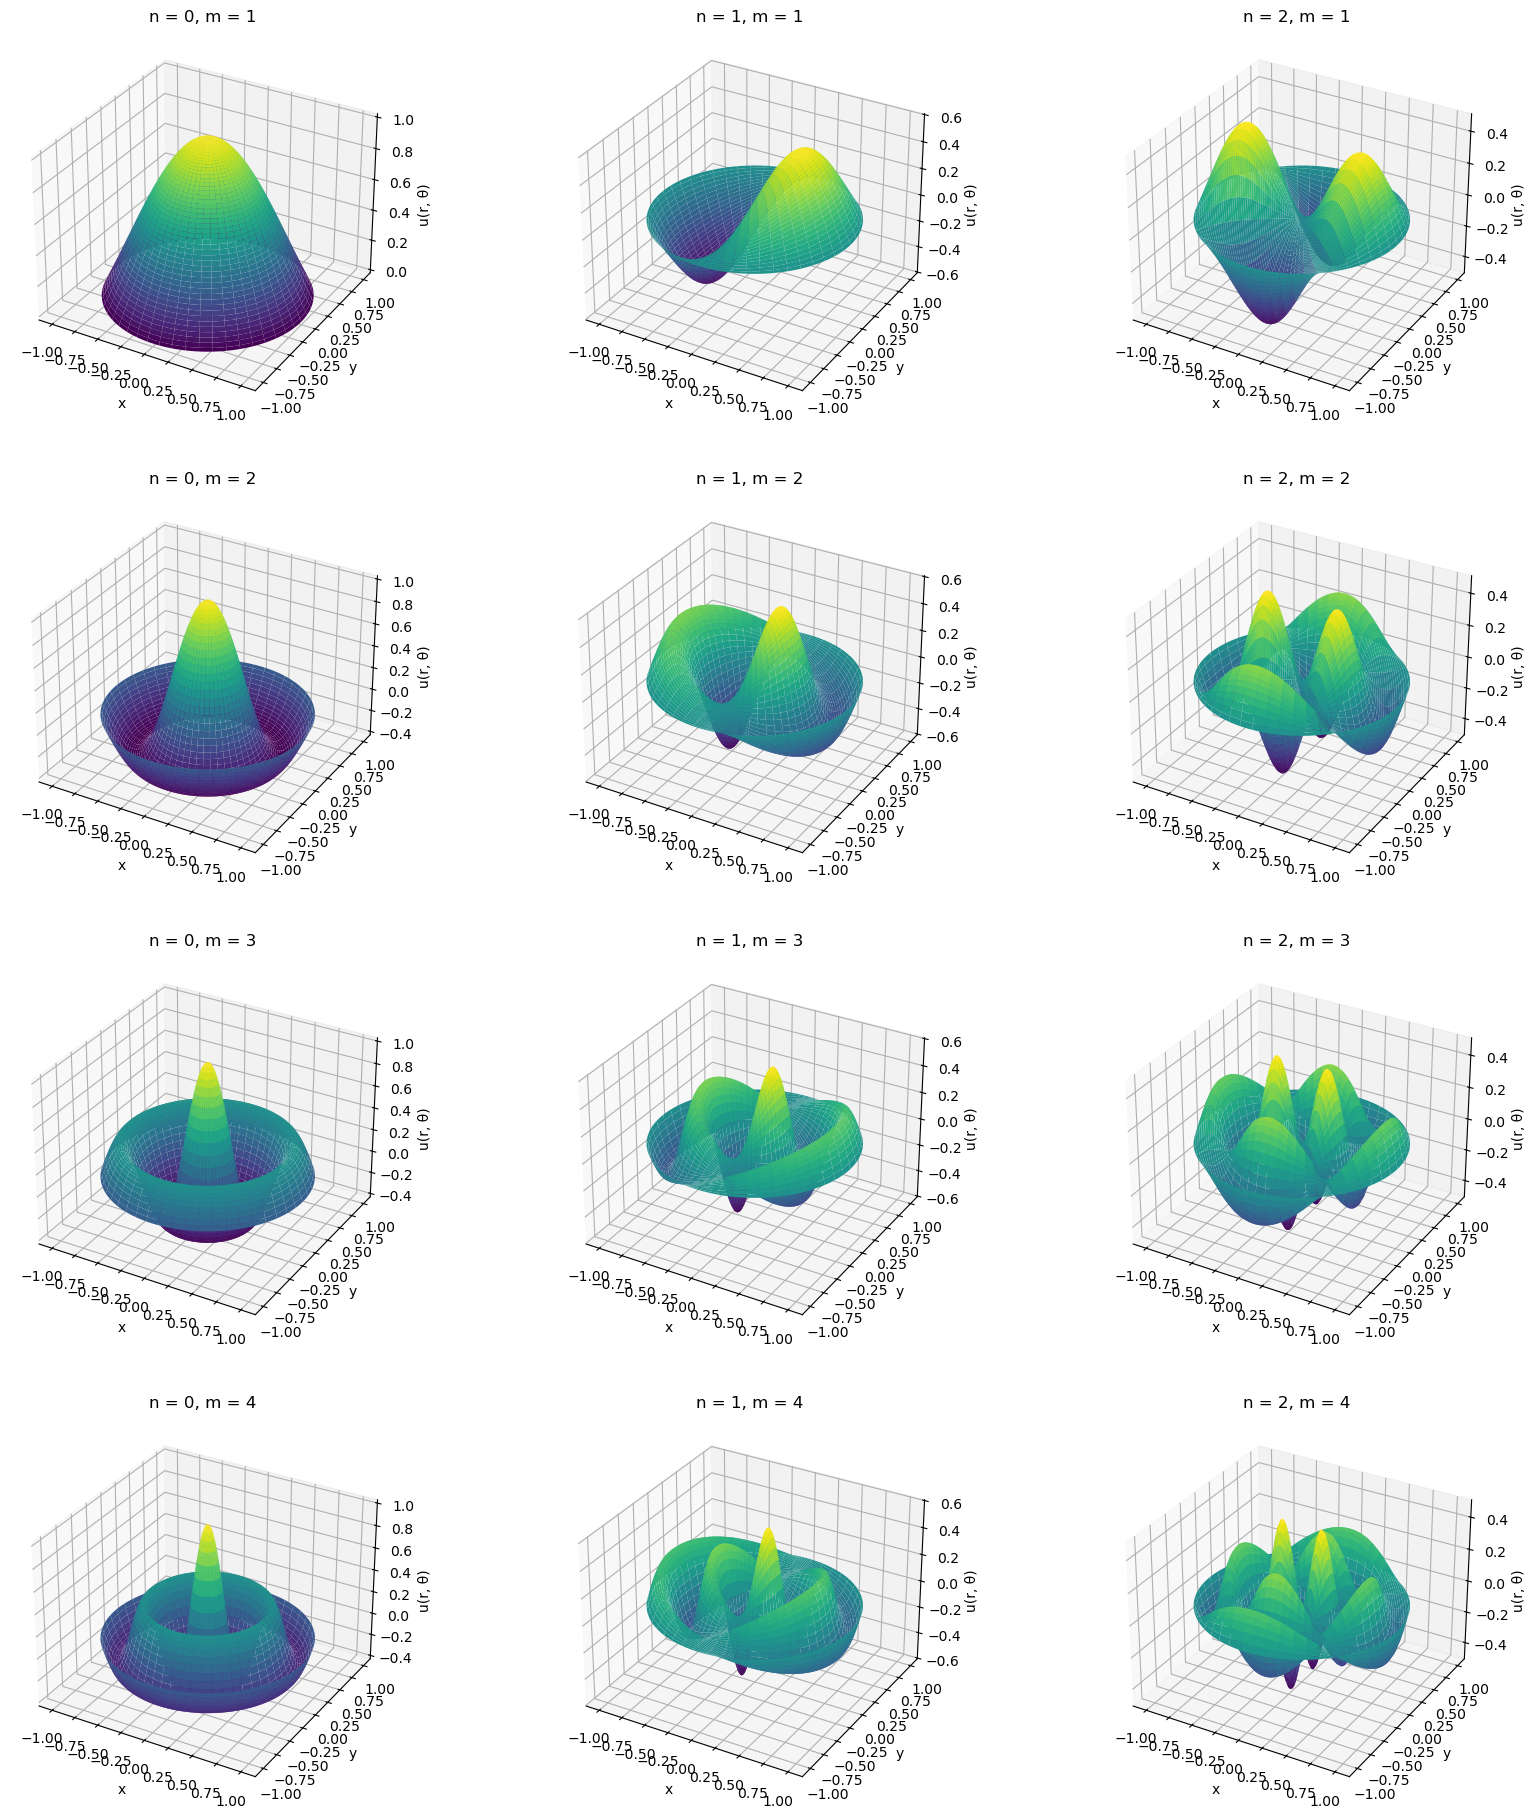

In [5]:
# Set up a grid in r-theta coordinates
radial_points = np.linspace(0, 1, N)
angular_points = np.linspace(0, 2*np.pi, 6*N)

r, theta = np.meshgrid(radial_points, angular_points)

# Convert polar grid to Cartesian coordinates for 3D plotting
X = r * np.cos(theta)
Y = r * np.sin(theta)


# Compute a real-valued eigenmode
def mode_shape(n, m, r, theta):
    # Zeros of J_n(k)
    k = float(besseljzero(n, m, 0))

    return ss.jv(n, k*r) * np.cos(n*theta)


# Choose modes to display
n_values = range(0, 3)
m_values = range(1, 5)


# -------------------
# Polar contour plots
# -------------------

fig, axes = plt.subplots(
    len(m_values),
    len(n_values),
    figsize = (20, 25),
    subplot_kw = {"projection": "polar"}
)

for row, m in enumerate(m_values):
    for col, n in enumerate(n_values):

        u = mode_shape(n, m, r, theta)
        ax = axes[row, col]

        ax.set_xlim(0, 2*np.pi)
        ax.set_xticks(np.arange(0, 2*np.pi, np.pi/2))
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 1])
        ax.set_title(f"n = {n}, m = {m}")

        ax.contourf(theta, r, u, levels = 40, cmap = "viridis")

        # Draw the boundary of the disk
        ax.contour(theta, r, r, levels = [0.999], colors = "black")

plt.tight_layout()
plt.show()


# ----------------
# 3D surface plots
# ----------------

fig, axes = plt.subplots(
    len(m_values),
    len(n_values),
    figsize = (20, 23),
    subplot_kw = {"projection": "3d"}
)

for row, m in enumerate(m_values):
    for col, n in enumerate(n_values):

        u = mode_shape(n, m, r, theta)
        ax = axes[row, col]

        ax.plot_surface(X, Y, u, cmap = "viridis")
        ax.set_title(f"n = {n}, m = {m}")

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        # Manual z-label, more reliable than ax.set_zlabel for 3D plots
        ax.text2D(1.06, 0.5, "u(r, θ)", transform = ax.transAxes, rotation = 90)

plt.show()

## Orthogonality and Normalization

The radial Bessel functions form an orthogonal set with respect to the weighted inner product

$$
\langle f,g\rangle = \int_0^1 f(r)g(r) \, r \, dr
$$

For fixed $n$, this gives

$$
D^{(n)}_{ab}
=
\int_0^1 J_n(k_{n,a}r)J_n(k_{n,b}r) \, r \, dr
$$

When $a\neq b$, this inner product should vanish. When $a = b$, it gives the normalization factor

$$
D^{(n)}_{mm}
=
\int_0^1 \left(J_n(k_{n,m}r)\right)^2 \, r \, dr
$$

These normalization factors are needed when projecting an initial condition onto the eigenmodes.

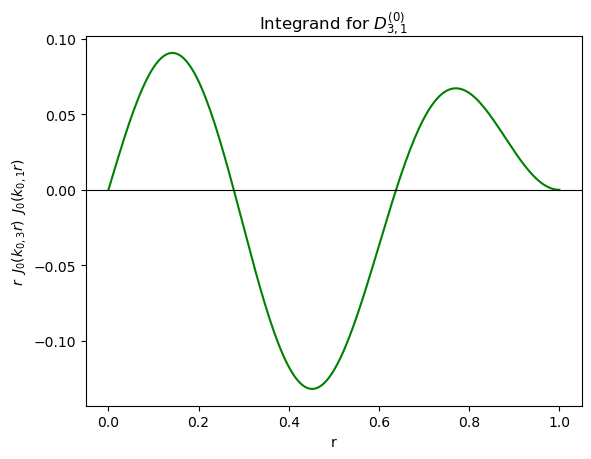

Rough integral estimate: D^(0)_3,1 = -2.104431e-06
Accurate integral: D^(0)_3,1 = 2.621804e-18
Estimated error: 6.92e-13
Norm integral: D^(0)_3,3 = 3.684318e-02
Estimated error: 4.40e-16


In [6]:
# -----------------------------
# Inner product of radial modes
# -----------------------------

# Choose which radial modes to compare
# n is the Bessel order; a and b label different radial modes
n = 0
a = 3
b = 1

# Get the wavenumbers k_(n,a) and k_(n,b)
# zeros of J_n(k)
kna = float(besseljzero(n, a, 0))
knb = float(besseljzero(n, b, 0))



# Define integrand
def radial_inner_product_integrand(r, n, k1, k2):
    return r * ss.jv(n, k1*r) * ss.jv(n, k2*r)


# Create points in r to visualize the integrand
r_values = np.linspace(0, 1, N)

integrand = radial_inner_product_integrand(r_values, n, kna, knb)


# Plot integrand
plt.plot(r_values, integrand, 'g-')
plt.axhline(0, color = "black", linewidth = 0.8)

plt.title(rf"Integrand for $D^{{({n})}}_{{{a},{b}}}$")
plt.xlabel("r")
plt.ylabel(rf"$r \; \; J_{n}(k_{{{n},{a}}}r) \; \; J_{n}(k_{{{n},{b}}}r)$")

plt.show()


# Numerical integration
# Rough estimate using trapezoidal rule
Dnab_rough = np.trapezoid(integrand, r_values)
print(f"Rough integral estimate: D^({n})_{a},{b} = {Dnab_rough:.6e}")

# More accurate integral using scipy.integrate.quad
Dnab, err = scipy.integrate.quad(
    radial_inner_product_integrand, 0, 1, args = (n, kna, knb)
)

print(f"Accurate integral: D^({n})_{a},{b} = {Dnab:.6e}")
print(f"Estimated error: {err:.2e}")


# Norm of a single mode
m = 3
knm = float(besseljzero(n, m, 0))

Dnmm, err = scipy.integrate.quad(
    lambda r: r * (ss.jv(n, knm*r))**2, 0, 1
)

print(f"Norm integral: D^({n})_{m},{m} = {Dnmm:.6e}")
print(f"Estimated error: {err:.2e}")

## Time Evolution of the System

We now construct a time-dependent solution describing wave-like motion on the disk. So far, we have solved the Laplacian eigenvalue problem on a disk, obtaining a complete set of spatial eigenfunctions

$$
\phi_{n,m}(r,\theta) = J_n(k_{n,m} r)\, e^{i n \theta}
$$

with eigenvalues $k_{n,m}^2$

To describe time-dependent behaviour, we now consider the wave equation

$$
\frac{\partial^2 u}{\partial t^2} = \nabla^2 u
$$

We look for solutions of the form

$$
u(r,\theta,t) = \phi_{n,m}(r,\theta)\, T(t)
$$

Substituting into the wave equation gives

$$
T''(t)\,\phi_{n,m} = T(t)\,\nabla^2 \phi_{n,m}
$$

Using the eigenvalue equation

$$
\nabla^2 \phi_{n,m} = -k_{n,m}^2 \phi_{n,m}
$$

we obtain an equation for the time dependence:

$$
T''(t) + k_{n,m}^2 T(t) = 0
$$

This is the equation of a simple harmonic oscillator, with solutions

$$
T(t) = A_{n,m}\cos(k_{n,m} t) + B_{n,m}\sin(k_{n,m} t)
$$

The full solution is therefore a superposition of oscillating modes:

$$
u(r,\theta,t) = \sum_{n,m} \left( A_{n,m}\cos(k_{n,m} t) + B_{n,m}\sin(k_{n,m} t) \right) \, \, \phi_{n,m}(r,\theta)
$$

The coefficients $A_{n,m}$ and $B_{n,m}$ are determined by the initial conditions.

### Imposing initial conditions

We consider the case where the initial displacement is zero,

$$
u(r,\theta,0) = 0
$$

but the system has a nonzero initial velocity.

Substituting $t = 0$ into the general solution gives
$$
u(r,\theta,0) = \sum_{n,m} A_{n,m} J_n(k_{n,m} r)\, e^{i n \theta}
$$

For this to vanish everywhere, we must have
$$
A_{n,m} = 0 \quad \text{for all} \; n,m
$$

The solution therefore simplifies to
$$
u(r,\theta,t) = \sum_{n,m} c_{n,m} \, J_n(k_{n,m} r) \, e^{i n \theta} \, \sin(k_{n,m} t)
$$

(we take $B_{n,m} = c_{n,m}$)

### Initial velocity condition

Taking a time derivative, we obtain

$$ \frac{\partial u}{\partial t}(r,\theta,t) =
\sum_{n,m} c_{n,m} \, k_{n,m} \, J_n(k_{n,m} r) \, e^{i n \theta} \, \cos(k_{n,m} t)
$$

Evaluating at $t = 0$ gives

$$ \dot{u}(r,\theta,0) =
\sum_{n,m} c_{n,m} \, k_{n,m} \, J_n(k_{n,m} r) \, e^{i n \theta}
$$

This must match the prescribed initial velocity profile.

### Interpretation

The coefficients $c_{n,m}$ determine how strongly each mode contributes to the motion. Physically, the initial velocity distribution is decomposed into a sum of eigenmodes, each of which oscillates independently with frequency $k_{n,m}$.

In the next section, we compute these coefficients explicitly by projecting the initial condition onto the eigenfunctions.

### Computing the coefficients from the initial conditions

We now construct a time-dependent solution subject to the condition that the initial displacement is zero, while the initial velocity is nonzero. This constraint determines the form of the time dependence.

Since we require  
$$
u(r,\theta,0) = 0
$$
the natural choice is a sine dependence in time, as $\sin(ckt) = 0$ at $t = 0$, while its time derivative is nonzero. For simplicity, we set the wave speed $c = 1$ in what follows.

The general solution can therefore be written as
$$
u(r,\theta,t) = \sum_{n,m} c_{n,m}\, J_n(k_{n,m} r)\, e^{i n \theta}\, \sin(k_{n,m} t)
$$

Taking a time derivative, we obtain the velocity field:
$$
\frac{\partial u}{\partial t}(r,\theta,t) 
= \sum_{n,m} c_{n,m}\, k_{n,m}\, J_n(k_{n,m} r)\, e^{i n \theta}\, \cos(k_{n,m} t)
$$

Evaluating this at $t = 0$, we find
$$
\dot{u}(r,\theta,0) = \sum_{n,m} c_{nm}\, k_{n,m}\, J_n(k_{n,m} r)\, e^{i n \theta}
$$
which defines the prescribed initial velocity profile.

---

### Choosing an initial condition

We take the initial velocity to be localized near the point
$$
r = \frac{1}{3}, \quad \theta = 0
$$
with the disk radius normalized to $R = 1$.

This allows us to interpret the expansion coefficients $c_{n,m}$ as projections of the initial condition onto the eigenfunctions of the system.

---

### Determining the coefficients

Using orthogonality of the eigenfunctions, the coefficients can be obtained via an inner product. In this case, the projection simplifies to evaluating the mode shape at the point where the initial condition is concentrated. This leads to

$$
c_{n,m} = \frac{1}{k_{n,m}} \, J_n\ (k_{n,m}/3) \, \frac{1}{D_{mm}^{(n)}}
$$

where the normalization factor is given by
$$
D_{mm}^{(n)} = \int_0^1 r \left(J_n(k_{n,m} r)\right)^2 \, dr
$$

---

### Practical implementation

We assume that a sorted list of eigenvalues $k_{n,m}$ has already been computed. The final step is to choose how many modes to include in the expansion. 

In practice, we begin with a small number of modes (for example, three) to observe the basic behaviour, and then increase the number to improve the accuracy of the solution.

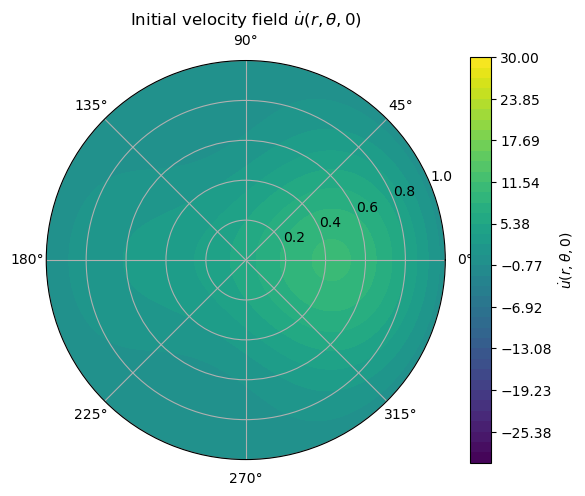

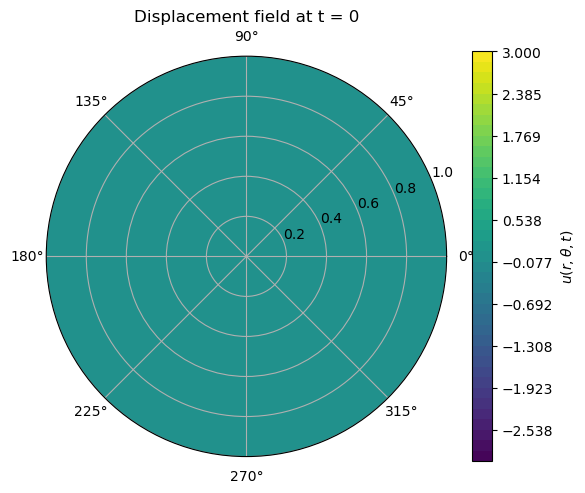

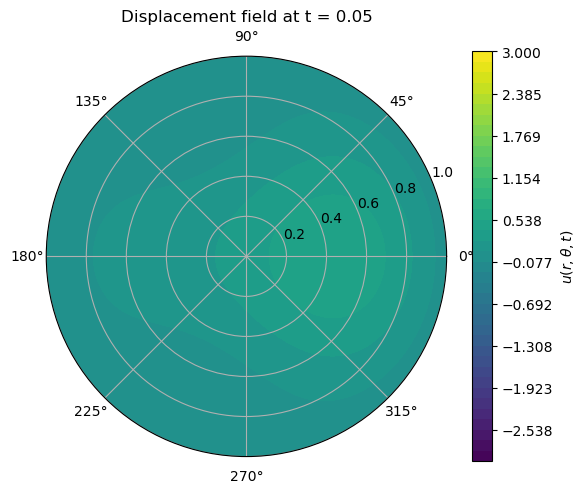

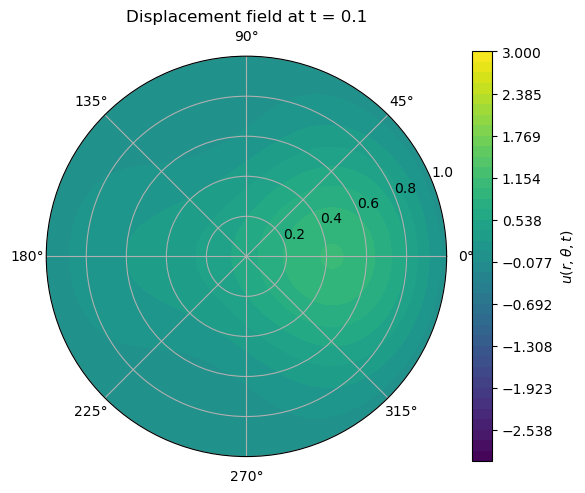

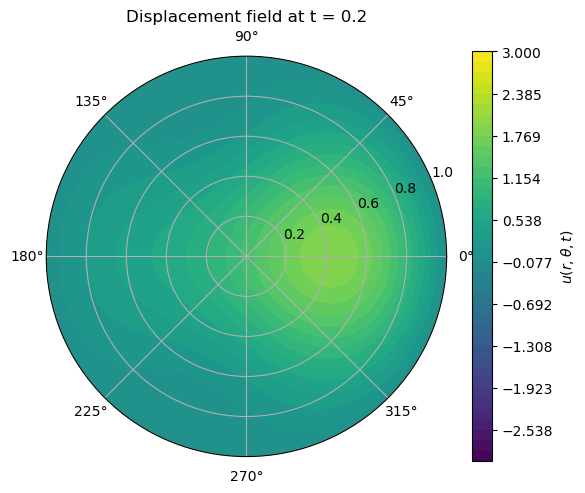

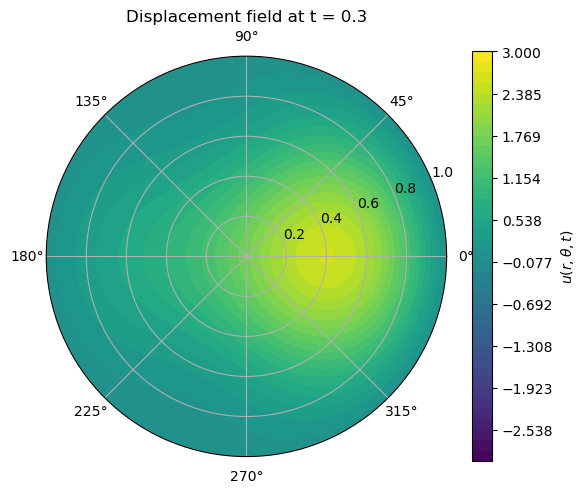

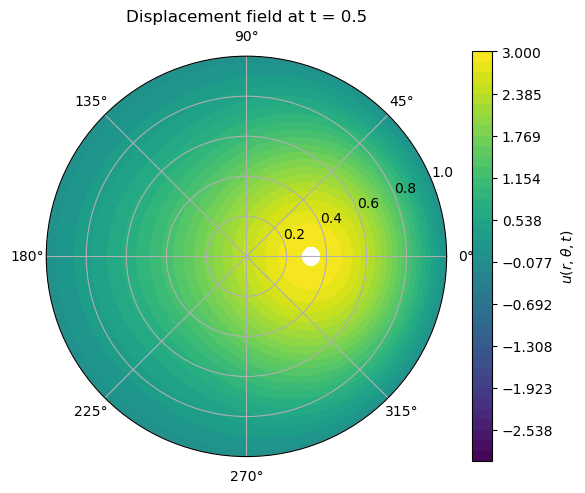

In [7]:
# --------------------------------------------------------------
# Compute modal coefficients from the initial velocity condition
# --------------------------------------------------------------

# Set up a grid in polar coordinates on the unit disk
radial_points = np.linspace(0, 1, N)
angular_points = np.linspace(0, 2*np.pi, 6*N)

r, theta = np.meshgrid(radial_points, angular_points)


# Choose how many nonzero modes to include
num_coefficients = 3

# Exclude the zero-frequency mode
nonzero_modes = [mode for mode in modes if mode[0] > 1e-12]

# Select the first few nonzero modes
selected_modes = nonzero_modes[:num_coefficients]


# Compute normalization integral D^n_mm
def mode_norm(n, k):
    Dnmm, err = scipy.integrate.quad(
        lambda x: x * (ss.jv(n, k*x))**2,
        0,
        1
    )
 
    return Dnmm


# Compute coefficient for a localized initial velocity near r = 1/3, theta = 0
def mode_coefficient(n, k, r0 = 1/3):
    Dnmm = mode_norm(n, k)

    return ss.jv(n, k*r0) / (k * Dnmm)


# Compute coefficients for selected modes
coefficients = []

for k, n, m in selected_modes:
    c = mode_coefficient(n, k)
    coefficients.append(c)


# Build initial velocity field u_dot(r, theta, 0)
u_dot = np.zeros_like(r)

for coefficient, (k, n, m) in zip(coefficients, selected_modes):
    u_dot += (
        coefficient
        * k
        * ss.jv(n, k*r)
        * np.cos(n*theta)
    )


# Plot initial velocity field
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw = {"projection": "polar"})

contour = ax.contourf(
    theta,
    r,
    u_dot,
    levels = np.linspace(-30, 30, 40),
    cmap = "viridis"
)

fig.colorbar(contour, ax = ax, label = r"$\dot{u}(r,\theta,0)$")

ax.set_title(r"Initial velocity field $\dot{u}(r,\theta,0)$")

plt.tight_layout()
plt.show()


# Build displacement field u(r, theta, t)
def displacement_field(t):
    u = np.zeros_like(r)

    for coefficient, (k, n, m) in zip(coefficients, selected_modes):
        u += (
            coefficient
            * ss.jv(n, k*r)
            * np.cos(n*theta)
            * np.sin(k*t)
        )

    return u


# Plot displacement at several times
times = [0, 0.05, 0.1, 0.2, 0.3, 0.5]

for t in times:
    u = displacement_field(t)

    fig, ax = plt.subplots(figsize = (6, 5), subplot_kw = {"projection": "polar"})

    contour = ax.contourf(
        theta,
        r,
        u,
        levels=np.linspace(-3, 3, 40),
        cmap = "viridis"
    )

    fig.colorbar(contour, ax = ax, label = r"$u(r,\theta,t)$")

    ax.set_title(f"Displacement field at t = {t}")

    plt.tight_layout()
    plt.show()

## Increasing the Number of Modes

Using only a few modes gives a rough approximation to the initial velocity profile. By including more modes, the expansion can represent a more localized initial disturbance. The tradeoff is that higher modes introduce finer spatial structure and require more computation.

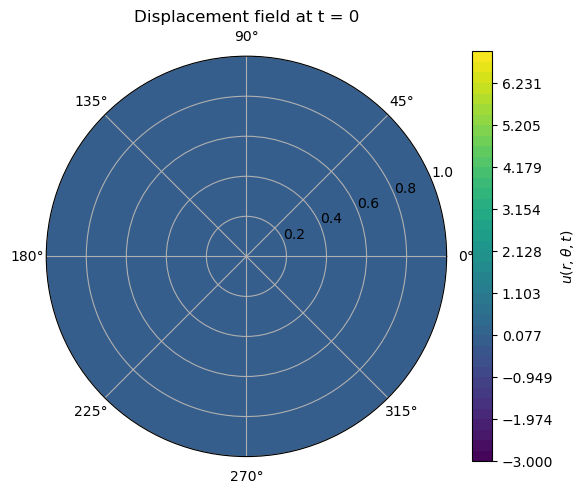

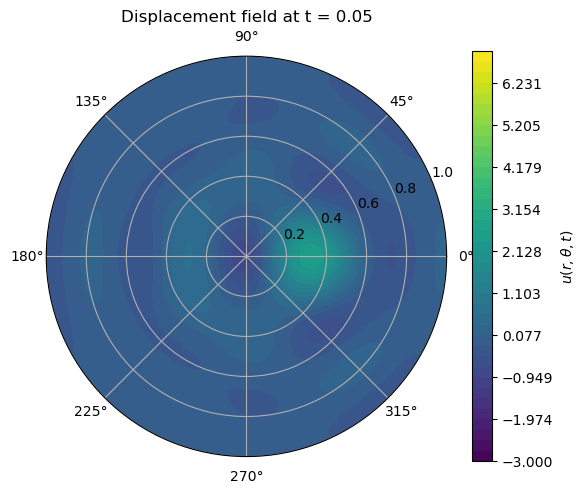

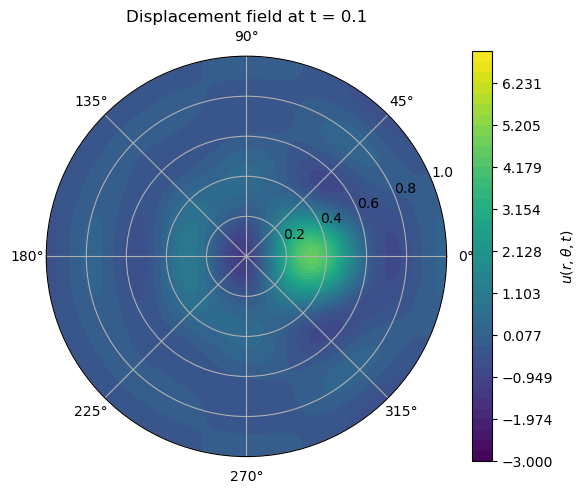

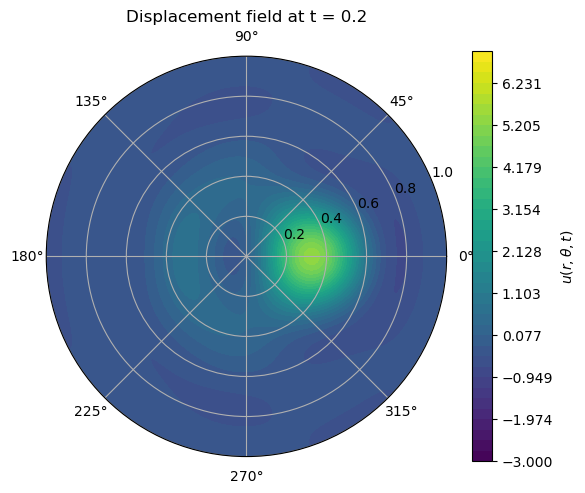

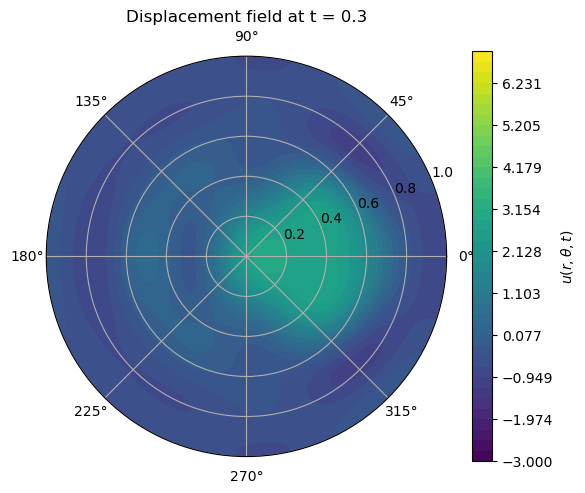

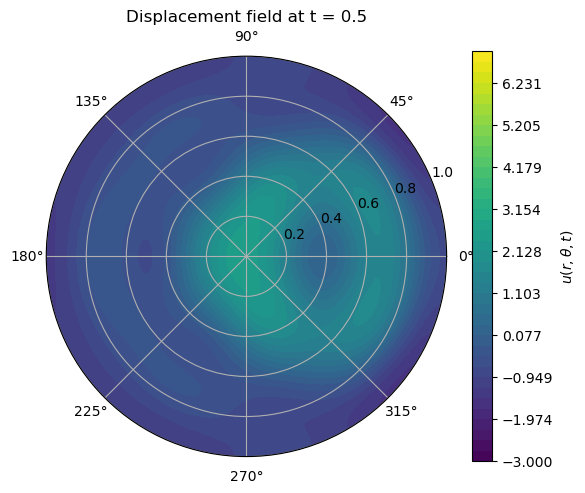

In [8]:
# -------------------------------
# Time evolution using many modes
# -------------------------------

# Choose boundary condition
# "free"  -> zeros of J_n'(k), Neumann boundary condition
# "fixed" -> zeros of J_n(k), Dirichlet boundary condition
boundary_condition = "free"

zero_type = 1 if boundary_condition == "free" else 0


# Build and sort mode list
def compute_modes(n_max, m_max, zero_type):
    modes = []

    for n in range(n_max):
        for m in range(1, m_max + 1):
            k = float(besseljzero(n, m, zero_type))
            modes.append((k, n, m))

    modes.sort(key = lambda mode: mode[0])
    return modes


modes = compute_modes(n_max = 20, m_max = 29, zero_type = zero_type)


# Set up polar grid
radial_points = np.linspace(0, 1, N)
angular_points = np.linspace(0, 2*np.pi, 6*N)

r, theta = np.meshgrid(radial_points, angular_points)


# Select modes

num_coefficients = 30

# For free boundary conditions, remove the zero-frequency mode
if boundary_condition == "free":
    selected_modes = [mode for mode in modes if mode[0] > 1e-12][:num_coefficients]
else:
    selected_modes = modes[:num_coefficients]


# Compute modal coefficients
def mode_norm(n, k):
    Dnmm, err = scipy.integrate.quad(
        lambda x: x * (ss.jv(n, k*x))**2,
        0,
        1
    )

    return Dnmm


def mode_coefficient(n, k, r0 = 1/3):
    # Projection coefficient for an initial velocity localized near r = r0
    Dnmm = mode_norm(n, k)
    return ss.jv(n, k*r0) / (k * Dnmm)


coefficients = [
    mode_coefficient(n, k)
    for k, n, m in selected_modes
]


# Displacement field from modal expansion
def displacement_field(t):
    u = np.zeros_like(r)

    for coefficient, (k, n, m) in zip(coefficients, selected_modes):
        u += (
            coefficient
            * ss.jv(n, k*r)
            * np.cos(n*theta)
            * np.sin(k*t)
        )

    return u


# Plot time evolution
times = [0, 0.05, 0.1, 0.2, 0.3, 0.5]
for t in times:
    u = displacement_field(t)

    fig, ax = plt.subplots(figsize=(6, 5), subplot_kw = {"projection": "polar"})

    contour = ax.contourf(
        theta,
        r,
        u,
        levels=np.linspace(-3, 7, 40),
        cmap = "viridis"
    )

    fig.colorbar(contour, ax = ax, label = r"$u(r,\theta,t)$")

    ax.set_title(f"Displacement field at t = {t}")

    plt.tight_layout()
    plt.show()

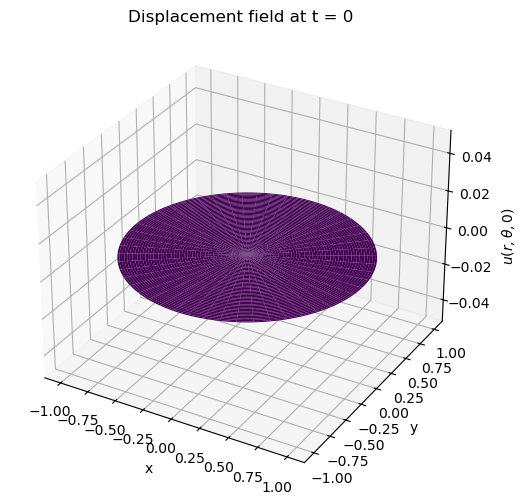

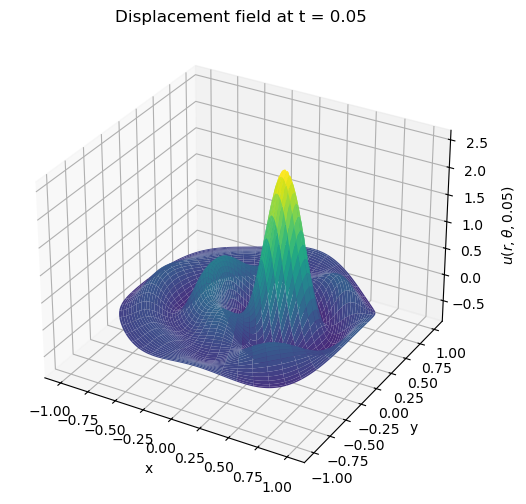

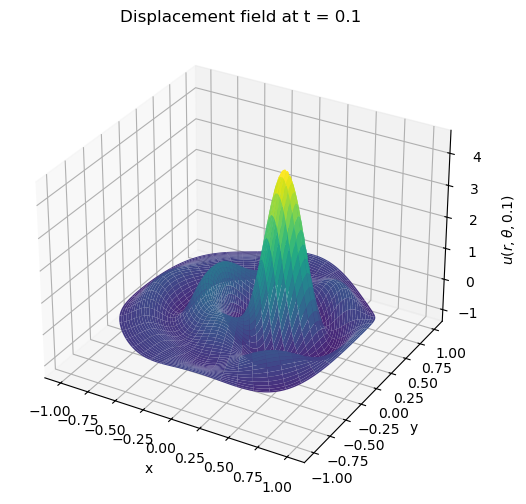

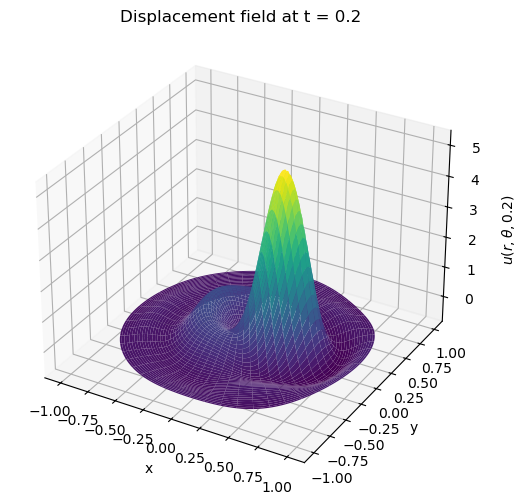

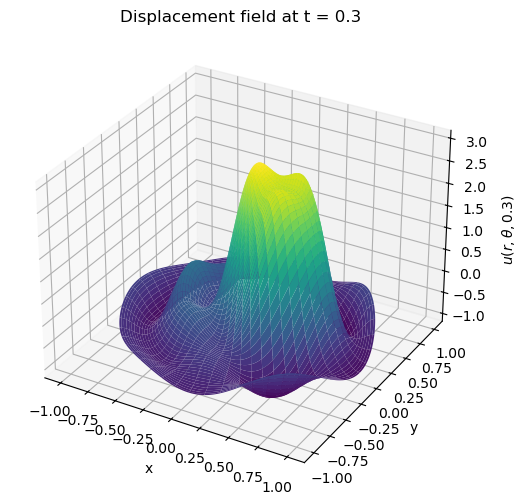

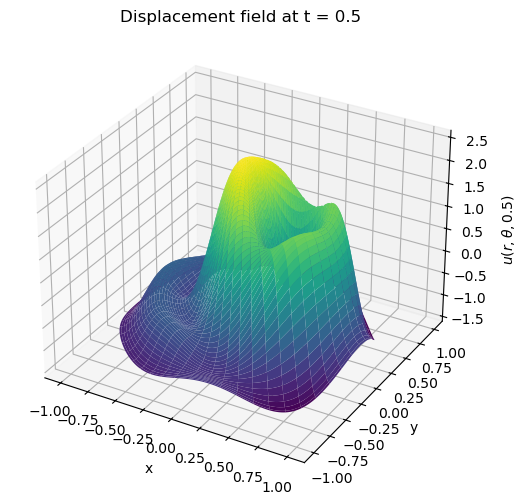

In [9]:
# ------------------------------------------
# 3D surface plots of the displacement field
# ------------------------------------------

# Convert polar grid to Cartesian coordinates for 3D plotting
X = r * np.cos(theta)
Y = r * np.sin(theta)

# Plot the displacement field at several times
times = [0, 0.05, 0.1, 0.2, 0.3, 0.5]

for t in times:

    # Compute displacement field using the modal expansion
    u = displacement_field(t)

    # Plot completed displacement field as a 3D surface
    fig, ax = plt.subplots(figsize = (8, 6), subplot_kw = {"projection": "3d"})

    ax.plot_surface(X, Y, u, cmap = "viridis")

    ax.set_title(f"Displacement field at t = {t}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # Manual z-label is more reliable than ax.set_zlabel for 3D plots
    # because Matplotlib often clips 3D z-axis labels
    ax.text2D(1.06, 0.5, rf"$u(r,\theta,{t})$", transform = ax.transAxes, rotation = 90)

    plt.show()